## Building Fast Queries on a CSV input file

Using the `csv` module, we can import the `laptops.csv` file. To simulate opening a file with unknown encoding, we will additionally use the `chardet` module.

In [1]:
from csv import reader
import chardet

with open('laptops.csv', mode = 'rb') as file:
    raw_bytes = file.read()
    encoding = chardet.detect(raw_bytes)['encoding']

with open('laptops.csv', mode = 'r', encoding = encoding) as file:
    read_file = list(reader(file))

header = read_file[0]
rows = read_file[1:]

print(f'The file was encoded using {encoding}')
print(f'The file has {len(rows)} rows.')
print(f'The file has {len(header)} columns.\n')
print('The header row is as follows:\n')
print(header)

The file was encoded using utf-8
The file has 1303 rows.
The file has 13 columns.

The header row is as follows:

['Id', 'Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price']


In [2]:
print('The first five row are as follows:\n')
for i in range(5):
    print(f'Row number {i + 1}:\n{rows[i]}')

The first five row are as follows:

Row number 1:
['6571244', 'Apple', 'MacBook Pro', 'Ultrabook', '13.3', 'IPS Panel Retina Display 2560x1600', 'Intel Core i5 2.3GHz', '8GB', '128GB SSD', 'Intel Iris Plus Graphics 640', 'macOS', '1.37kg', '1339']
Row number 2:
['7287764', 'Apple', 'Macbook Air', 'Ultrabook', '13.3', '1440x900', 'Intel Core i5 1.8GHz', '8GB', '128GB Flash Storage', 'Intel HD Graphics 6000', 'macOS', '1.34kg', '898']
Row number 3:
['3362737', 'HP', '250 G6', 'Notebook', '15.6', 'Full HD 1920x1080', 'Intel Core i5 7200U 2.5GHz', '8GB', '256GB SSD', 'Intel HD Graphics 620', 'No OS', '1.86kg', '575']
Row number 4:
['9722156', 'Apple', 'MacBook Pro', 'Ultrabook', '15.4', 'IPS Panel Retina Display 2880x1800', 'Intel Core i7 2.7GHz', '16GB', '512GB SSD', 'AMD Radeon Pro 455', 'macOS', '1.83kg', '2537']
Row number 5:
['8550527', 'Apple', 'MacBook Pro', 'Ultrabook', '13.3', 'IPS Panel Retina Display 2560x1600', 'Intel Core i5 3.1GHz', '8GB', '256GB SSD', 'Intel Iris Plus Graphi

### Exploring the Data

When exploring the data, we note the following column types:
- **ID**: A unique identifier for the laptop
- **Company**: The name of the company that manufactured the laptop _(e.g., Dell, HP, Lenovo, etc.)_
- **Product**: The name of the laptop model _(e.g., XPS 13, Surface Pro, etc.)_
- **TypeName**: The type of laptop _(e.g., Desktop, Laptop, Netbook, etc.)_
- **Inches**: The diagonal screen size of the laptop in inches _(e.g., 13.3, 15.6, etc.)_
- **ScreenResolution**: The resolution of the laptop's screen _(e.g., 1920x1080, 2560x1440, etc.)_
- **CPU**: The laptop CPU _(e.g., Intel Core i5, AMD Ryzen 7, etc.)_
- **RAM**: The amount of RAM in the laptop _(e.g., 8GB, 16GB, etc.)_
- **Memory**: The amount of storage in the laptop _(e.g., 256GB SSD, 1TB HDD, etc.)_
- **GPU**: The laptop GPU _(e.g., NVIDIA GeForce GTX 1650, AMD Radeon RX 5500M, etc.)_
- **OpSys**: The operating system installed on the laptop _(e.g., Windows 10, macOS, Linux, etc.)_
- **Weight**: The weight of the laptop in grams _(e.g., 1.2kg, 2.5kg, etc.)_
- **Price**: The price of the laptop in dollars _(e.g., 799, 1299, etc.)_

## Building an Inventory Class

For this demonstration, we will build a class that represents the inventory of laptops, which would allow us to potentially open multiple CSV files and perform various operations on the data. This first segment of code explores how we would build the `Inventory` class, which would contain the details of our `laptops.csv`.

We will later build additional defined functions within this class that will help us answer the following queries:
1. Given a laptop ID, find the corresponding data.
2. Given an amount of money, find whether there are two laptops whose total price is that given amount.
3. Identify all laptops whose price falls within a given budget.


In [3]:
from csv import reader
import chardet

class Inventory:

    def __init__(self, csv_filename):
        with open(csv_filename, mode = 'rb') as file:
            raw_bytes = file.read()
            encoding = chardet.detect(raw_bytes)['encoding']

        with open(csv_filename, mode = 'r', encoding = encoding) as file:
            read_file = list(reader(file))

        self.header = read_file[0]
        self.rows = read_file[1:]

        # Converting string values to appropriate formats
        for row in self.rows:
            row[self.header.index('Price')] = int(row[self.header.index('Price')])

# Testing the Inventory class
inventory = Inventory('laptops.csv')
print(f'The header of the inventory class is:\n{inventory.header}\n')
print(f'The inventory class contains {len(inventory.rows)} rows of data.')

The header of the inventory class is:
['Id', 'Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price']

The inventory class contains 1303 rows of data.


## Laptop ID Lookup

For this demonstration, we will tackle the first challenge:
> 1. Given a laptop ID, find the corresponding data.

We will start this by building a simple `get_laptop_from_id` function that will take the identifier of the laptop as an argument and return the corresponding row of data.


In [4]:
from csv import reader
import chardet

class Inventory:

    def __init__(self, csv_filename):
        with open(csv_filename, mode = 'rb') as file:
            raw_bytes = file.read()
            encoding = chardet.detect(raw_bytes)['encoding']

        with open(csv_filename, mode = 'r', encoding = encoding) as file:
            read_file = list(reader(file))

        self.header = read_file[0]
        self.rows = read_file[1:]

        for row in self.rows:
            row[self.header.index('Price')] = int(row[self.header.index('Price')]) # Price

    def get_laptop_from_id(self, laptop_id):
        for row in self.rows:
            if row[self.header.index('Id')] == laptop_id:
                return row
        return None

inventory = Inventory('laptops.csv')

#Test the output with a known and a false laptop IDs, i.e., a positive and negative test
print(f'The positive test is run for laptop ID: 3362737. The return we get is:\n{inventory.get_laptop_from_id('3362737')}\n')
print(f'The negative test is run for laptop ID: 3362736. The return we get is:\n{inventory.get_laptop_from_id('3362736')}\n')

The positive test is run for laptop ID: 3362737. The return we get is:
['3362737', 'HP', '250 G6', 'Notebook', '15.6', 'Full HD 1920x1080', 'Intel Core i5 7200U 2.5GHz', '8GB', '256GB SSD', 'Intel HD Graphics 620', 'No OS', '1.86kg', 575]

The negative test is run for laptop ID: 3362736. The return we get is:
None



This algorithm has a **time complexity of $O(n)$**, where n is the number of rows in the CSV file. This is because the function iterates through each row in the file to find the laptop with the given ID. While this may not be the most efficient approach for large datasets, it is a simple and straightforward solution that can be easily understood and implemented.

We can improve the efficiency of this algorithm by using a data structure such as a dictionary, which would allow us to retrieve the laptop with a given ID in **constant time, i.e., $O(1)$**. However, this would require additional memory and would be more complex to implement. An example of such an implementation can be seen below.

In [5]:
from csv import reader
import chardet

class Inventory:

    def __init__(self, csv_filename):
        with open(csv_filename, mode = 'rb') as file:
            raw_bytes = file.read()
            encoding = chardet.detect(raw_bytes)['encoding']

        with open(csv_filename, mode = 'r', encoding = encoding) as file:
            read_file = list(reader(file))

        self.header = read_file[0]
        self.rows = read_file[1:]

        for row in self.rows:
            row[self.header.index('Price')] = int(row[self.header.index('Price')]) # Price

        self.id_to_row = {}
        for row in self.rows:
            self.id_to_row[row[self.header.index('Id')]] = row

    def get_laptop_from_id(self, laptop_id):
        for row in self.rows:
            if row[self.header.index('Id')] == laptop_id:
                return row
        return None

    def get_laptop_from_id_fast(self, laptop_id):
        if self.id_to_row.get(laptop_id):
            return self.id_to_row.get(laptop_id)
        return None

inventory = Inventory('laptops.csv')

#Test the output with a known and a false laptop IDs, i.e., a positive and negative test
print(f'The positive test is run for laptop ID: 3362737. The return we get is:\n{inventory.get_laptop_from_id_fast('3362737')}\n')
print(f'The negative test is run for laptop ID: 3362736. The return we get is:\n{inventory.get_laptop_from_id_fast('3362736')}\n')

The positive test is run for laptop ID: 3362737. The return we get is:
['3362737', 'HP', '250 G6', 'Notebook', '15.6', 'Full HD 1920x1080', 'Intel Core i5 7200U 2.5GHz', '8GB', '256GB SSD', 'Intel HD Graphics 620', 'No OS', '1.86kg', 575]

The negative test is run for laptop ID: 3362736. The return we get is:
None



### Comparing the Performance

Below, we will run the two queries and compare their performance and determine which formula is faster, and the impact as the number of lookups increases.

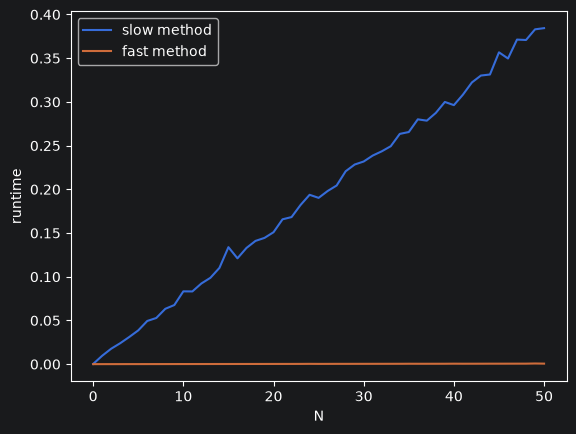

In [6]:
import time
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output

def scenario_comparison(series_1, series_2, series_1_name = '', series_2_name = '', ylabel = 'runtime', xlabel='N'):
    plt.plot(series_1, label=series_1_name)
    plt.plot(series_2, label=series_2_name)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.legend()
    plt.show()

total_time_no_dict = []
total_time_with_dict = []

# Using the get_laptop_from_id method
slow_speed = -100
for i in range(0, 5001, 100):
    ids = [str(random.randint(1000000, 9999999)) for _ in range(i+1)]
    start = time.time()
    for id in ids:
        inventory.get_laptop_from_id(id)
    end = time.time()
    total_time_no_dict.append(end - start)
    slow_speed += 100
    if slow_speed % 500 == 0:                           # Debug
        print(f'Completed for {i} lookups (slow)')      # Debug

fast_speed = -100
# Using the get_laptop_from_id_fast method
for i in range(0, 5001, 100):
    ids = [str(random.randint(1000000, 9999999)) for _ in range(i+1)]
    start = time.time()
    for id in ids:
        inventory.get_laptop_from_id_fast(id)
    end = time.time()
    total_time_with_dict.append(end - start)
    fast_speed += 100
    if fast_speed % 500 == 0:                           # Debug
        print(f'Completed for {i} lookups (fast)')      # Debug

clear_output(wait=True)

scenario_comparison(total_time_no_dict, total_time_with_dict, 'slow method', 'fast method')

Based on the plot, we can verify that the fast method is significantly faster than the slow method, especially as the number of lookups increases. This is because the fast method uses a dictionary to store the inventory data, which allows for constant-time lookups (i.e., $O(1)$), whereas the slow method uses a linear search through a list, which has a time complexity of $O(n)$.

## Two Laptop Promotions

For this demonstration, we will tackle the second challenge:
> 2. Given an amount of money, find whether there are two laptops whose total price is that given amount.

For context, sometimes, the store offers a promotion where you give a gift card. A customer can use the gift to buy up to two laptops. To avoid having to keep track of what was already spent, the gift card has a single time usage. This means that, even if there is leftover money, it cannot be used anymore. You don't want to make a customer feel cheated, so whenever you issue a gift card, you want to make sure that there is at least one way to spend it in full. In other words, before issuing a gift card for $D$ dollars, you want to make sure that either there is a laptop that costs exactly $D$ dollars or two laptops whose costs add up to precisely $D$ dollars.

We will start this by building a simple `check_promotion_dollars` function that will take the total dollar value of the gift card as an argument and return `True` or `False`, if two laptops add up to that exact price.


In [7]:
from csv import reader
import chardet

class Inventory:

    def __init__(self, csv_filename):
        with open(csv_filename, mode = 'rb') as file:
            raw_bytes = file.read()
            encoding = chardet.detect(raw_bytes)['encoding']

        with open(csv_filename, mode = 'r', encoding = encoding) as file:
            read_file = list(reader(file))

        self.header = read_file[0]
        self.rows = read_file[1:]

        for row in self.rows:
            row[self.header.index('Price')] = int(row[self.header.index('Price')]) # Price

        self.id_to_row = {}
        for row in self.rows:
            self.id_to_row[row[self.header.index('Id')]] = row

    def get_laptop_from_id(self, laptop_id):
        for row in self.rows:
            if row[self.header.index('Id')] == laptop_id:
                return row
        return None

    def get_laptop_from_id_fast(self, laptop_id):
        if self.id_to_row.get(laptop_id):
            return self.id_to_row.get(laptop_id)
        return None

    def check_promotion_dollars(self, dollars):
        for row in self.rows:
            if row[self.header.index('Price')] == dollars:
                return True, row
        for row1 in self.rows:
            for row2 in self.rows:
                if row1[self.header.index('Price')] + row2[self.header.index('Price')] == dollars:
                    return True, row1, row2
        return False

inventory = Inventory('laptops.csv')

# Test the output with a known valid gift card value for a single laptop, a combination of two laptops, or invalid gift card amount, i.e., a positive and negative test

def test_case(test_value):
    checker = inventory.check_promotion_dollars(test_value)

    if checker:
        if len(checker) == 2:  # One Laptop
            print(
                f"The positive test is run for a valid gift card value of ${test_value:,}. "
                f"The return we get is: {checker[0]}\n"
                f"This can be achieved by purchasing a single "
                f"{checker[1][inventory.header.index('Company')]} "
                f"{checker[1][inventory.header.index('Product')]} "
                f"at a cost of ${checker[1][inventory.header.index('Price')]:,}.\n"
            )

        else:  # Two Laptops
            print(
                f"The positive test is run for a valid gift card value of ${test_value:,}. "
                f"The return we get is: {checker[0]}\n"
                f"This can be achieved with a combination of a "
                f"{checker[1][inventory.header.index('Company')]} "
                f"{checker[1][inventory.header.index('Product')]} "
                f"at a cost of ${checker[1][inventory.header.index('Price')]:,} and a "
                f"{checker[2][inventory.header.index('Company')]} "
                f"{checker[2][inventory.header.index('Product')]} "
                f"at a cost of ${checker[2][inventory.header.index('Price')]:,}.\n"
            )

    else:
        print(
            f"The negative test is run for a gift card value of ${test_value:,}. "
            f"The return we get is: {checker}\n"
            f"No laptop or combination of two laptops can be purchased for exactly this amount.\n"
        )

test_case(1000) # Single
test_case(3297) # Double
test_case(442) # None

The positive test is run for a valid gift card value of $1,000. The return we get is: True
This can be achieved by purchasing a single HP EliteBook 840 at a cost of $1,000.

The positive test is run for a valid gift card value of $3,297. The return we get is: True
This can be achieved with a combination of a Apple MacBook Pro at a cost of $1,339 and a Apple MacBook Pro at a cost of $1,958.

The negative test is run for a gift card value of $442. The return we get is: False
No laptop or combination of two laptops can be purchased for exactly this amount.



This algorithm has a time complexity of $O(n^2)$, where n is the number of rows in the inventory. This is because the algorithm uses two nested loops to iterate through the rows, resulting in a quadratic time complexity.

We can improve the time complexity of this algorithm by changing our approach. If we store all the laptop prices in a set, we can check if a combination of two laptops adds up to the desired gift card value in constant time, resulting in a linear time complexity of $O(n)$. An example of such an implementation can be seen below:


In [8]:
from csv import reader
import chardet

class Inventory:

    def __init__(self, csv_filename):
        with open(csv_filename, mode = 'rb') as file:
            raw_bytes = file.read()
            encoding = chardet.detect(raw_bytes)['encoding']

        with open(csv_filename, mode = 'r', encoding = encoding) as file:
            read_file = list(reader(file))

        self.header = read_file[0]
        self.rows = read_file[1:]

        for row in self.rows:
            row[self.header.index('Price')] = int(row[self.header.index('Price')]) # Price

        self.id_to_row = {}
        for row in self.rows:
            self.id_to_row[row[self.header.index('Id')]] = row

        self.prices = []
        for row in self.rows:
            self.prices.append(row[self.header.index('Price')])

    def get_laptop_from_id(self, laptop_id):
        for row in self.rows:
            if row[self.header.index('Id')] == laptop_id:
                return row
        return None

    def get_laptop_from_id_fast(self, laptop_id):
        if self.id_to_row.get(laptop_id):
            return self.id_to_row.get(laptop_id)
        return None

    def check_promotion_dollars(self, dollars):
        for row in self.rows:
            if row[self.header.index('Price')] == dollars:
                return True, row, row
        for row1 in self.rows:
            for row2 in self.rows:
                if row1[self.header.index('Price')] + row2[self.header.index('Price')] == dollars:
                    return True, row1, row2
        return False

    def check_promotion_dollars_fast(self, dollars):
        if dollars in self.prices:
            return True, self.rows[self.prices.index(dollars)]
        for price in self.prices:
            complement = dollars - price
            if complement in self.prices:
                return True, self.rows[self.prices.index(price)], self.rows[self.prices.index(complement)]
        else:
            return False


inventory = Inventory('laptops.csv')

# Test the output with a known valid gift card value for a single laptop, a combination of two laptops, or invalid gift card amount, i.e., a positive and negative test

def test_case(test_value):
    checker = inventory.check_promotion_dollars_fast(test_value)

    if checker:
        if len(checker) == 2:  # One Laptop
            print(
                f"The positive test is run for a valid gift card value of ${test_value:,}. "
                f"The return we get is: {checker[0]}\n"
                f"This can be achieved by purchasing a single "
                f"{checker[1][inventory.header.index('Company')]} "
                f"{checker[1][inventory.header.index('Product')]} "
                f"at a cost of ${checker[1][inventory.header.index('Price')]:,}.\n"
            )

        else:  # Two Laptops
            print(
                f"The positive test is run for a valid gift card value of ${test_value:,}. "
                f"The return we get is: {checker[0]}\n"
                f"This can be achieved with a combination of a "
                f"{checker[1][inventory.header.index('Company')]} "
                f"{checker[1][inventory.header.index('Product')]} "
                f"at a cost of ${checker[1][inventory.header.index('Price')]:,} and a "
                f"{checker[2][inventory.header.index('Company')]} "
                f"{checker[2][inventory.header.index('Product')]} "
                f"at a cost of ${checker[2][inventory.header.index('Price')]:,}.\n"
            )

    else:
        print(
            f"The negative test is run for a gift card value of ${test_value:,}. "
            f"The return we get is: {checker}\n"
            f"No laptop or combination of two laptops can be purchased for exactly this amount.\n"
        )

test_case(1000) # Single
test_case(3297) # Double
test_case(442) # None

The positive test is run for a valid gift card value of $1,000. The return we get is: True
This can be achieved by purchasing a single HP EliteBook 840 at a cost of $1,000.

The positive test is run for a valid gift card value of $3,297. The return we get is: True
This can be achieved with a combination of a Apple MacBook Pro at a cost of $1,339 and a Apple MacBook Pro at a cost of $1,958.

The negative test is run for a gift card value of $442. The return we get is: False
No laptop or combination of two laptops can be purchased for exactly this amount.



### Comparing the Performance

Below, we will run the two queries and compare their performance and determine which formula is faster, and the impact as the number of lookups increases.

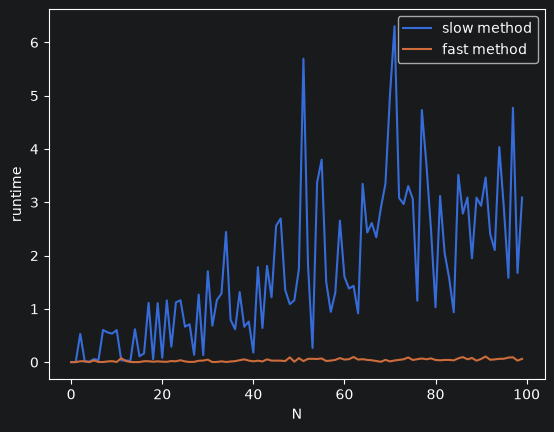

In [9]:
import time
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output

def scenario_comparison(series_1, series_2, series_1_name = '', series_2_name = '', ylabel = 'runtime', xlabel='N'):
    plt.plot(series_1, label=series_1_name)
    plt.plot(series_2, label=series_2_name)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.legend()
    plt.show()

total_time_no_set = []
total_time_with_set = []

# Using the get_laptop_from_id method
slow_speed = 0
for i in range(0, 100):
    prices = [random.randint(100, 5000) for _ in range(i+1)]
    start = time.time()
    for price in prices:
        inventory.check_promotion_dollars(price)
    end = time.time()
    total_time_no_set.append(end - start)
    slow_speed += 1
    if slow_speed % 10 == 0:                            # Debug
        print(f'Completed for {i+1} lookups (slow)')    # Debug

# Using the get_laptop_from_id_fast method
fast_speed = 0
for i in range(0, 100):
    prices = [random.randint(100, 5000) for _ in range(i+1)]
    start = time.time()
    for price in prices:
        inventory.check_promotion_dollars_fast(price)
    end = time.time()
    total_time_with_set.append(end - start)
    fast_speed += 1
    if fast_speed % 10 == 0:                            # Debug
        print(f'Completed for {i+1} lookups (fast)')    # Debug

clear_output(wait=True)

scenario_comparison(total_time_no_set, total_time_with_set, 'slow method', 'fast method')

Based on the plot, we can verify that the fast method is significantly faster than the slow method, especially as the number of lookups increases. This is because the fast method stores laptop prices in a set, allowing **constant-time membership checks $(O(1))$**. Since each price only needs to be examined once, the **overall time complexity of the algorithm is $O(n)$**. In contrast, the original implementation uses two nested loops to evaluate every possible pair of laptops, resulting in a quadratic **time complexity of $O(n^2)$**. As the size of the inventory grows, the performance difference between O(n) and O(n²) becomes increasingly significant.

## Finding Laptops Within a Budget

For this demonstration, we will tackle the second challenge:
> 3. Identify all laptops whose price falls within a given budget.

In this project, we are going to leverage and extend that algorithm to help a customer find all laptops that fall within their budget.
More formally, we want to write a method that efficiently answers the query: Given a budget of $D$ dollars, find all laptops whose price it at most $D$.

We will utilise a binary search algorithm to efficiently find all laptops within a given budget.

In [10]:
from csv import reader
import chardet

class Inventory:

    def __init__(self, csv_filename):
        with open(csv_filename, mode = 'rb') as file:
            raw_bytes = file.read()
            encoding = chardet.detect(raw_bytes)['encoding']

        with open(csv_filename, mode = 'r', encoding = encoding) as file:
            read_file = list(reader(file))

        self.header = read_file[0]
        self.rows = read_file[1:]

        price_idx = self.header.index('Price')
        id_idx = self.header.index('Id')

        for row in self.rows:
            row[price_idx] = int(row[price_idx]) # Price

        self.id_to_row = {}
        for row in self.rows:
            self.id_to_row[row[id_idx]] = row

        self.prices = []
        for row in self.rows:
            self.prices.append(row[price_idx])

        self.rows_by_price = sorted(self.rows, key=lambda row: row[price_idx])

    def get_laptop_from_id(self, laptop_id):
        id_idx = self.header.index('Id')
        for row in self.rows:
            if row[id_idx] == laptop_id:
                return row
        return None

    def get_laptop_from_id_fast(self, laptop_id):
        if self.id_to_row.get(laptop_id):
            return self.id_to_row.get(laptop_id)
        return None

    def check_promotion_dollars(self, dollars):
        price_idx = self.header.index('Price')
        for row in self.rows:
            if row[price_idx] == dollars:
                return True, row, row
        for row1 in self.rows:
            for row2 in self.rows:
                if row1[price_idx] + row2[price_idx] == dollars:
                    return True, row1, row2
        return False

    def check_promotion_dollars_fast(self, dollars):
        if dollars in self.prices:
            return True, self.rows[self.prices.index(dollars)]
        for price in self.prices:
            complement = dollars - price
            if complement in self.prices:
                return True, self.rows[self.prices.index(price)], self.rows[self.prices.index(complement)]
        else:
            return False

    def find_laptop_with_price(self, target_price):
        range_start = 0
        range_end = len(self.rows_by_price) - 1
        while range_start < range_end:
            range_middle = (range_start + range_end) // 2
            price = self.rows_by_price[range_middle][-1]
            if price == target_price:
                return range_middle, self.rows_by_price[range_middle]
            elif price < target_price:
                range_start = range_middle + 1
            else:
                range_end = range_middle - 1
        price = self.rows_by_price[range_start][-1]
        if price != target_price:
            return -1
        return range_start, self.rows_by_price[range_start]

    def find_first_laptop_more_expensive(self, target_price):
        range_start = 0
        range_end = len(self.rows_by_price) - 1
        while range_start < range_end:
            range_middle = (range_start + range_end) // 2
            price = self.rows_by_price[range_middle][-1]
            if price > target_price:
                range_end = range_middle
            else:
                range_start = range_middle + 1
        if self.rows_by_price[range_start][-1] <= target_price:
            return -1
        return range_start, self.rows_by_price[range_start]

inventory = Inventory('laptops.csv')

# Test the output with a laptop with a price above known thresholds (i.e., $1,000 and $10,000) to enable a positive and negative test
print(inventory.find_first_laptop_more_expensive(1000))
print(inventory.find_first_laptop_more_expensive(10000))

(683, ['8747948', 'Lenovo', 'ThinkPad T460', 'Notebook', '14', '1366x768', 'Intel Core i5 6200U 2.3GHz', '4GB', '508GB Hybrid', 'Intel HD Graphics 520', 'Windows 7', '1.70kg', 1002])
-1


Based on the above, the `find_first_laptop_more_expensive` method correctly finds the first laptop with a price greater than the target price. It uses a binary search approach to efficiently locate the desired laptop in the sorted list of prices. The method returns the index and the corresponding row of the laptop if found, or -1 if no laptop with a higher price is present in the inventory.